# Cell Phenotyping

---
**Outline:**
1. STEP 1. Load the required R packages
2. STEP 2. Set the working directory
3. STEP 3. Read steinbock output into R
4. STEP 4. Inspect the object
5. STEP 5. Create transformed expression values
6. STEP 6. Check which markers are available
7. STEP 7. Define phenotype markers
8. STEP 8. Run UMAP for visualization
9. STEP 9. Cluster the cells
10. STEP 10. Plot clusters on UMAP
11. STEP 11. Sample a subset of cells for heatmap plotting
12. STEP 12. Plot heatmap of markers expression accross clusters
13. STEP 13. Inspect important markers one by one accross clusters
14. STEP 14. Assign biological cell-type names to clusters
15. STEP 15. Visualize annotated cell types on UMAP
16. STEP 16. Check counts per sample or image
17. STEP 17. Save the analyzed object
18. STEP 18. Visualize final annotation
19. STEP 19. Spatial Biology
---


## 1. STEP 1. Load the required R packages


In [49]:
# This loads the R packages for the analysis
library(imcRtools) # reads steinbock IMC output
library(SpatialExperiment) # stores cell level data
library(SingleCellExperiment) # stores cell level data
library(scater) # dimension reduction and visualization
library(scran) # clustering
library(bluster) # clustering
library(CATALYST) # IMC/CYTOF style clustering tools
library(dittoSeq) # easy plotting of cluters and marker expression
library(viridis) # color palettes
library(tidyverse) # data handling

---

## 2. STEP 2. Set the working directory


In [50]:
setwd("/Users/rashid/1_IMC_Analysis/8_analyze_20260116_TMA")

In [51]:
getwd()

[1] "/Users/rashid/1_IMC_Analysis/8_analyze_20260116_TMA"

---

## 2.1 Intermediate step. Create images.csv

In [52]:
images <- data.frame(
  image = "ROI001_D13",
  width_px = 1000,
  height_px = 1000
)

write.csv(images, "data/images.csv", row.names = FALSE, quote = FALSE)
read.csv("data/images.csv")

image,width_px,height_px
<chr>,<int>,<int>
ROI001_D13,1000,1000


## 3. STEP 3. Read steinbock output into R


In [53]:
spe <- read_steinbock(
  path = "data",
  intensities = "intensities",
  regionprops = "regionprops",
  panel = "panel.csv"
)

---

## 4. STEP 4. Inspect the object


In [54]:
spe

class: SpatialExperiment 
dim: 43 332 
metadata(0):
assays(1): counts
rownames(43): CD20 127I ... aSMA 80ArAr
rowData names(4): channel name keep deepcell
colnames(332): ROI001_D13_1 ROI001_D13_2 ... ROI001_D13_331
  ROI001_D13_332
colData names(8): sample_id ObjectNumber ... width_px height_px
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : Pos_X Pos_Y
imgData names(1): sample_id

In [55]:
# number of rows (markers) = 40
# number of columns (cells) = 47859

dim(spe)

[1]  43 332

In [56]:
# name of the assay (which matrices are stored)
assayNames(spe)

[1] "counts"

In [57]:
# metadata for cells such as sample id, area etc.
head(colData(spe))

DataFrame with 6 rows and 8 columns
               sample_id ObjectNumber      area axis_major_length
             <character>    <numeric> <numeric>         <numeric>
ROI001_D13_1  ROI001_D13            1        44          13.57480
ROI001_D13_2  ROI001_D13            2        44          13.18327
ROI001_D13_3  ROI001_D13            3         4           2.00000
ROI001_D13_4  ROI001_D13            4        56           9.97021
ROI001_D13_5  ROI001_D13            5       151          16.75673
ROI001_D13_6  ROI001_D13            6         5           3.09839
             axis_minor_length eccentricity  width_px height_px
                     <numeric>    <numeric> <numeric> <numeric>
ROI001_D13_1           4.12380     0.952741      1000      1000
ROI001_D13_2           4.25467     0.946490      1000      1000
ROI001_D13_3           2.00000     0.000000      1000      1000
ROI001_D13_4           7.20919     0.690771      1000      1000
ROI001_D13_5          12.05335     0.694685      100

In [58]:
# metadata of markers such as channel name, channel id etc,
head(rowData(spe))

DataFrame with 6 rows and 4 columns
          channel        name      keep  deepcell
      <character> <character> <numeric> <numeric>
CD20        115In        CD20         1        NA
127I         127I        127I         1        NA
131Xe       131Xe       131Xe         1        NA
134Xe       134Xe       134Xe         1        NA
138Ba       138Ba       138Ba         1        NA
CD68        141Pr        CD68         1        NA

In [59]:
# it shows the names of all markers in the data
rownames(spe)

[1] "CD20"      "127I"      "131Xe"     "134Xe"     "138Ba"     "CD68"     
 [7] "CD138"     "CD47"      "CD31"      "Tbet"      "BCL2"      "CD44"     
[13] "CD163"     "CD45RO"    "PDL1"      "MHC_II"    "CD66b"     "LAG3"     
[19] "TIM3"      "FoxP3"     "CD4"       "CTLA4"     "Brachiury" "CD11c"    
[25] "CD86"      "CD8"       "ERG"       "S100"      "PD1"       "GranzymeB"
[31] "CD56"      "CD3"       "CD21"      "CD10"      "Ki67"      "CD72a"    
[37] "GATA3"     "CD80"      "DNA1"      "DNA2"      "208Pb"     "aSMA"     
[43] "80ArAr"

---

## 5. STEP 5. Create transformed expression values

- This creates a new assay called "exprs" using arcsinh-transformed intensities.
- Raw IMC intensities are usually skewed. A few very bright cells can dominate the signal. The arcsinh transformation compresses extreme values and makes markers more comparable across cells.
- This is standard in IMC and CyTOF analysis
- the /5 is commonly used cofactor in IMC/CyTOF workflows. It controls the strength of the transformation. 


In [60]:
assay(spe, "exprs") <- asinh(assay(spe, "counts") / 5)

In [61]:
assayNames(spe)

[1] "counts" "exprs"

---

## 6. STEP 6. Check which markers are available


In [62]:
# displays the marker names in the data
rownames(spe)

[1] "CD20"      "127I"      "131Xe"     "134Xe"     "138Ba"     "CD68"     
 [7] "CD138"     "CD47"      "CD31"      "Tbet"      "BCL2"      "CD44"     
[13] "CD163"     "CD45RO"    "PDL1"      "MHC_II"    "CD66b"     "LAG3"     
[19] "TIM3"      "FoxP3"     "CD4"       "CTLA4"     "Brachiury" "CD11c"    
[25] "CD86"      "CD8"       "ERG"       "S100"      "PD1"       "GranzymeB"
[31] "CD56"      "CD3"       "CD21"      "CD10"      "Ki67"      "CD72a"    
[37] "GATA3"     "CD80"      "DNA1"      "DNA2"      "208Pb"     "aSMA"     
[43] "80ArAr"

For phenotyping, we do not want to cluster using every marker blindly. We want to choose markers that define cell identity, such as:
- immune markers
- stromal markers
- tumor markers

---

## 7. STEP 7. Define phenotype markers

- This step creates a list of markers that will be used for cell phenotyping.
- Some markers tell **who the cell is**, while others tell **what the cell is doing**.
- So for clustering we will use only those markers which tell **who the cell is** and use them as identity markers.
- Hence, we will not use all the markers

####  *** Marker-Based Cell Type Identification Examples ***

| Markers               | Defines / Helps Identify            |
|----------------------|------------------------------------|
| CD3, CD4, CD8a       | T-cell types                       |
| CD20                 | B cells                            |
| FOXP3                | Regulatory T cells (Tregs)         |
| SMA, PDGFRb          | Stromal cells                      |
| Ecad or PanCK        | Tumor / epithelial cells           |
| HLADR                | Myeloid / APC-like cells           |
| MPO, CD15            | Neutrophils                        | 

In [63]:
##- Following will create a list of markers that will be used for cell phenotyping

phenotype_markers <- c(
  # Tumor / epithelial
  "Ecad",
  # Stroma
  "SMA", "PDGFRb",
  # Immune lineage
  "CD45",
  # T cells
  "CD3", "CD4", "CD8a",
  # B cells
  "CD20",
  # Plasma cells
  "CD38",
  # Myeloid
  "CD68", "CD163", "HLADR", "CD11c", "CD14",
  # Treg
  "FOXP3",
  # Neutrophils
  "MPO", "CD15"
)

In [64]:
# Following code will remove markers that are not present in the current dataset
phenotype_markers <- phenotype_markers[phenotype_markers %in% rownames(spe)]
phenotype_markers

[1] "CD3"   "CD4"   "CD20"  "CD68"  "CD163" "CD11c"

---

## 8. STEP 8. Run UMAP for visualization

- This step calculates a UMAP embedding of the cells.
- UMAP is a way to project high-dimensional data into 2 dimensions so one can visualize it.
- The data containing cells may have expression values for many markers. UMAP compresses that information into a 2D map, where **similar cells appear closer together and different cell populations separate into groups**.
- Clustering alone gives numbers, but UMAP helps in seeing structure in the data.
- Usually no direct plot appears yet, but the UMAP coordinates are stored inside spe.


In [65]:
set.seed(123)

spe <- runUMAP(
  spe,
  exprs_values = "exprs",
  # to use only phenotype markers, not all rows (markers) to make the embedding more relevant to cell identity
  subset_row = phenotype_markers 
)

---

## 9. STEP 9. Cluster the cells


**What the following code does**
- It groups cells into clusters based on similarity in marker expression
- Cell phenotyping often starts by clustering cells into groups, then inspecting what markers define each group
- This clustering is done by **SNN graph clustering**:
     - cells are connected to similar
     - a graph is built
     - Louvain community detection finds groups in the graph

In [66]:
set.seed(123)


clusters <- clusterCells(
  spe[phenotype_markers, ],
  assay.type = "exprs",
  BLUSPARAM = SNNGraphParam(
    k = 20, # each cell is connected to its nearest 20 neighbours
    cluster.fun = "louvain", # It uses Louvain algorithm to detect communities in the graph
    type = "jaccard" #  It uses shared-neighbour overlap as the edge weight. This is common and robust
  )
)

In [67]:
# Following adds the cluster label to the cell metadata so one can plot and analyze it later
spe$nn_clusters <- factor(clusters)

# Following will show how many cells are in each cluster
table(spe$nn_clusters)


 1  2  3  4  5 
66 60 65 85 56 

---

## 10. STEP 10. Plot clusters on UMAP

- This shows UMAP with cells **coloured by cluster**
- One can visually inspect now: 1) how many groups exist, 2) wheter clusters separate clearly, 3) whether some clusters overlap heavily
- a 2D scatter plot is generated where **each dot represents a cell**. Different colours represent different clusters
- GOOD: 1) clusters form visible groups, 2) labels sit near meaningful regions
- BAD: 1) one giant mixed cloud with little separation, 2) many tiny noisy clusters


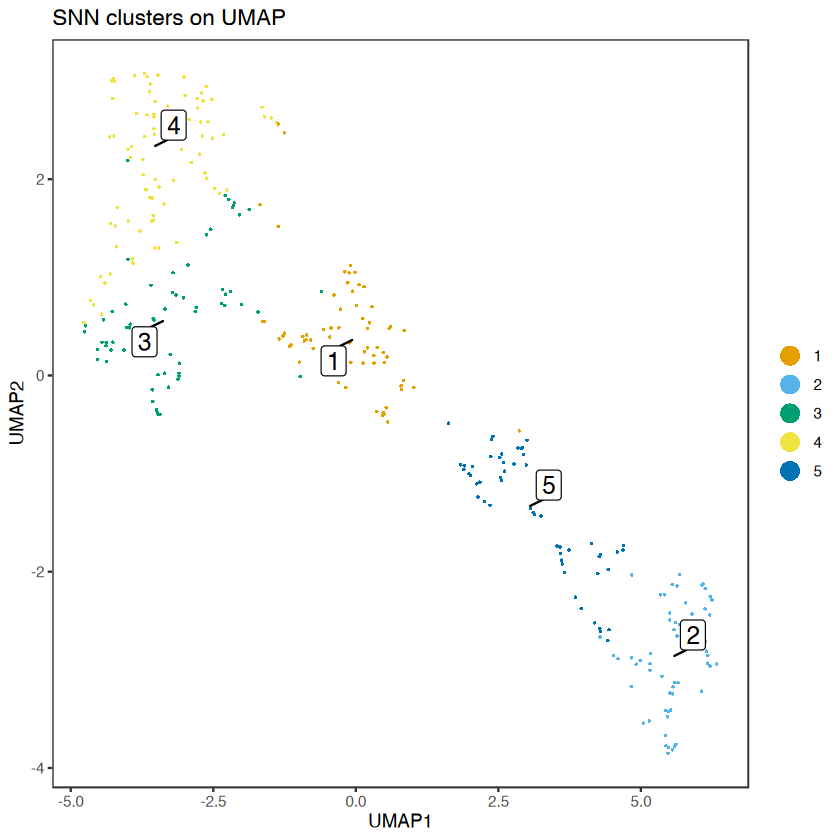

In [68]:
dittoDimPlot(
  spe,
  var = "nn_clusters",
  reduction.use = "UMAP",
  size = 0.4,
  do.label = TRUE
) + ggtitle("SNN clusters on UMAP")

---

## 11. STEP 11. Sample a subset of cells for heatmap plotting

- This selects randomly upto 2000 cells.
- Visualizing all cells will be difficult because heatmaps of all cells can become too large and unreadable. So sampling makes the heatmap manageable
- It would print a number, usually 2000 celss unless the data has fewer cells

In [69]:
set.seed(220619)
cur_cells <- sample(seq_len(ncol(spe)), min(2000, ncol(spe)))
length(cur_cells)

[1] 332

---

## 12. STEP 12. Plot heatmap of markers expression accross clusters

- This plots a heatmap of marker expression for sampled cells, annotated by cluster.
- It is one of the most important steps in phenotyping because it tells:
  - which clusters are CD3-high?
  - which clusters are CD20-high?
  - which clusters are SMA-high?
  - which clusters are FOXP3-high?


#### Cluster Interpretation Cheat Sheet

| Question / Pattern                          | Interpretation / Likely Cell Type |
|--------------------------------------------|----------------------------------|
| CD3-high clusters                           | T-cell populations               |
| CD20-high clusters                          | B cells                          |
| SMA-high clusters                           | Stromal cells                    |
| FOXP3-high clusters                         | Regulatory T cells (Tregs)       |
| High CD3 + CD8a                             | CD8 T cells                      |
| High CD3 + CD4                              | CD4 T cells                      |
| High CD20                                   | B cells                          |
| High FOXP3                                  | Tregs                            |
| High SMA / PDGFRb                           | Stroma                           |
| High Ecad / PanCK                           | Tumor / epithelial cells         |
| High HLADR                                  | Myeloid / APC-like cells         |
| High MPO / CD15                             | Neutrophils                      |

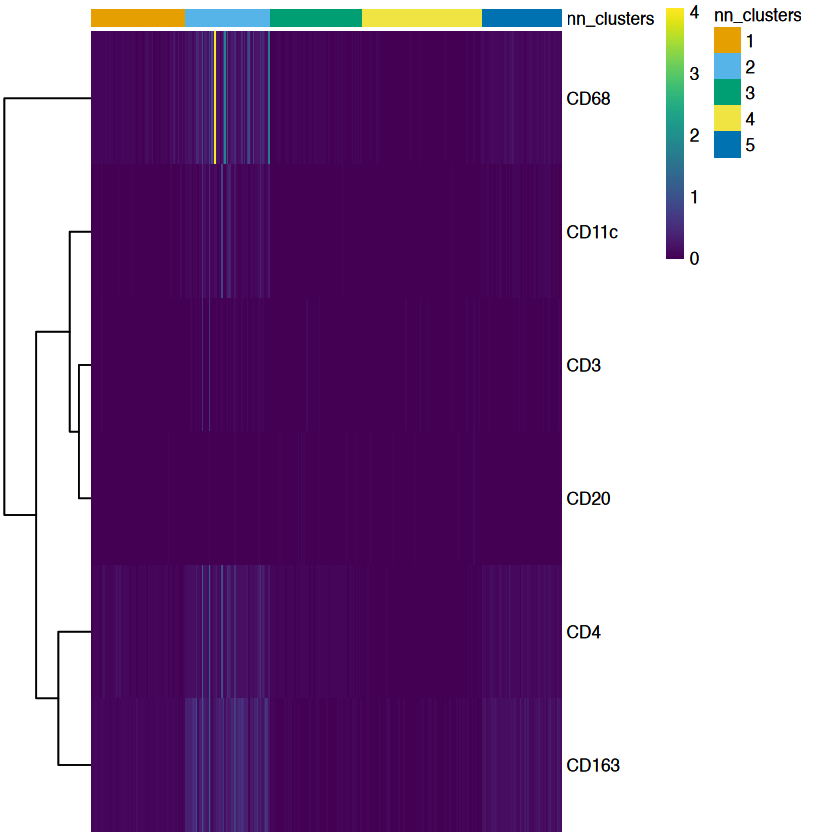

In [70]:
dittoHeatmap(
  spe[, cur_cells],
  genes = phenotype_markers,
  assay = "exprs",
  scale = "none",
  heatmap.colors = viridis(100),
  annot.by = "nn_clusters"
)

In [71]:
library(grid)

graphics.off()

ht <- dittoHeatmap(
  spe[, cur_cells],
  genes = phenotype_markers,
  assay = "exprs",
  scale = "none",
  heatmap.colors = viridis(100),
  annot.by = "nn_clusters"
)

pdf("heatmap_fixed.pdf", width = 10, height = 8)
grid::grid.newpage()
grid::grid.draw(ht$gtable)
dev.off()

pdf 
  2

In [72]:
file.info("heatmap_fixed.pdf")

,size,isdir,mode,mtime,ctime,atime,uid,gid,uname,grname
,<dbl>,<lgl>,<octmode>,<dttm>,<dttm>,<dttm>,<int>,<int>,<chr>,<chr>
heatmap_fixed.pdf,15250,FALSE,644,2026-03-31 09:35:01,2026-03-31 09:35:01,2026-03-31 09:26:05,502,20,rashid,staff


---

## 13. STEP 13. Inspect important markers one by one accross clusters

- The plots are shown for each marker. The plot shows expression of one marker at a time, grouped by cluster.
- The heatmap gives a broad overview, but these plots make it easir to confirm cluster identitiies.

#### Cluster-Based Interpretation Examples

| Cluster   | High Marker | Likely Cell Type |
|----------|------------|------------------|
| Cluster 4 | CD20       | B cells          |
| Cluster 7 | FOXP3      | Tregs            |
| Cluster 2 | Ecad       | Tumor cells      |


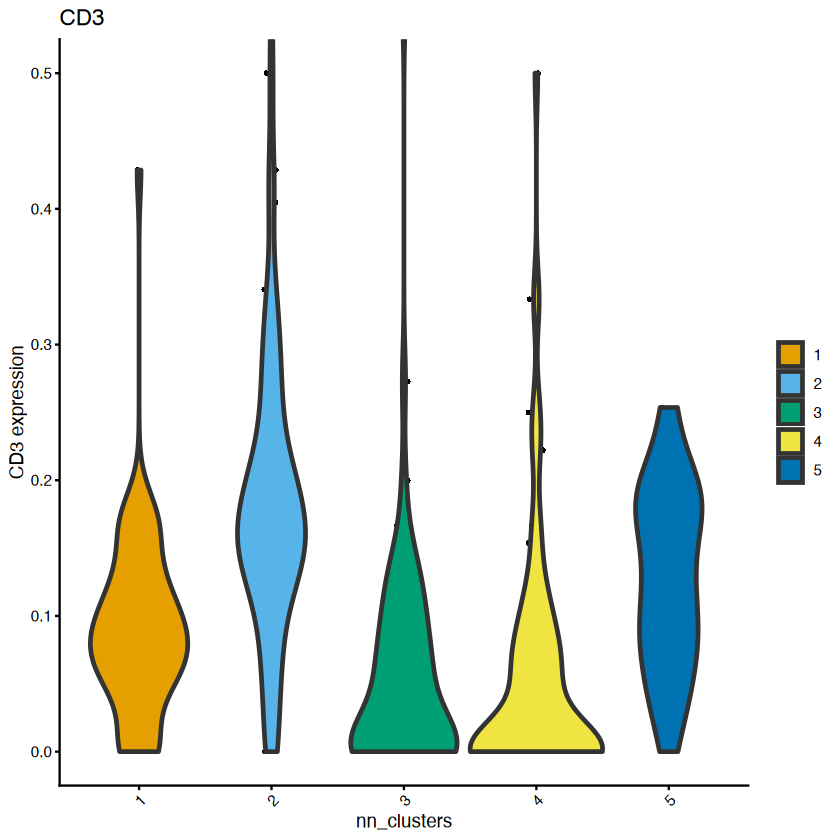

In [73]:
dittoPlot(spe, "CD3", group.by = "nn_clusters") +
 coord_cartesian(ylim = c(0, 0.5))

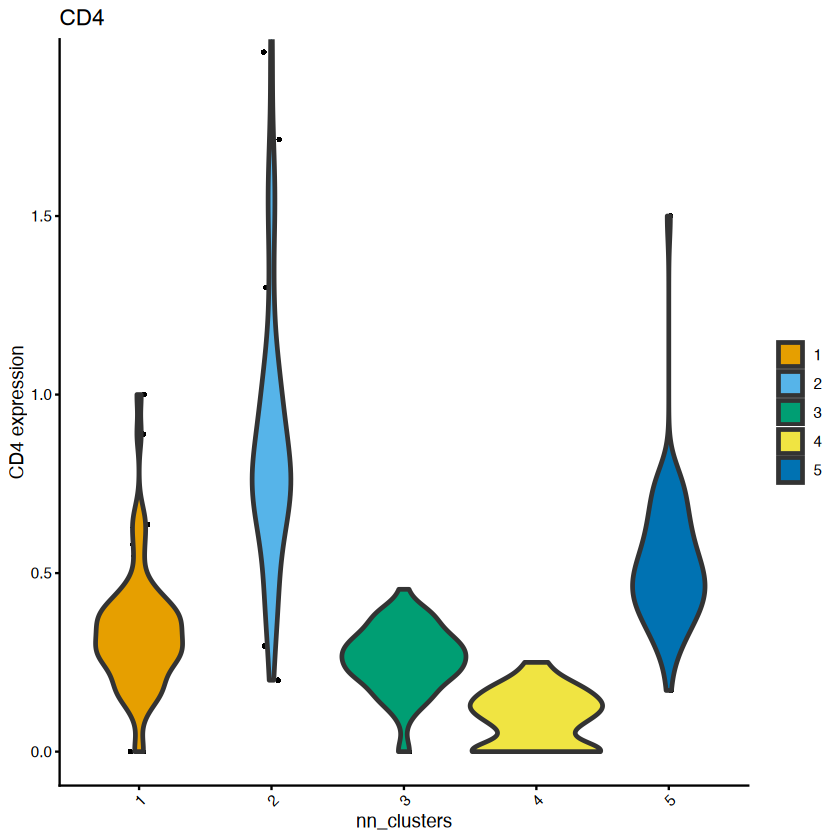

In [74]:
dittoPlot(spe, "CD4", group.by = "nn_clusters") +
coord_cartesian(ylim = c(0, 1.9))

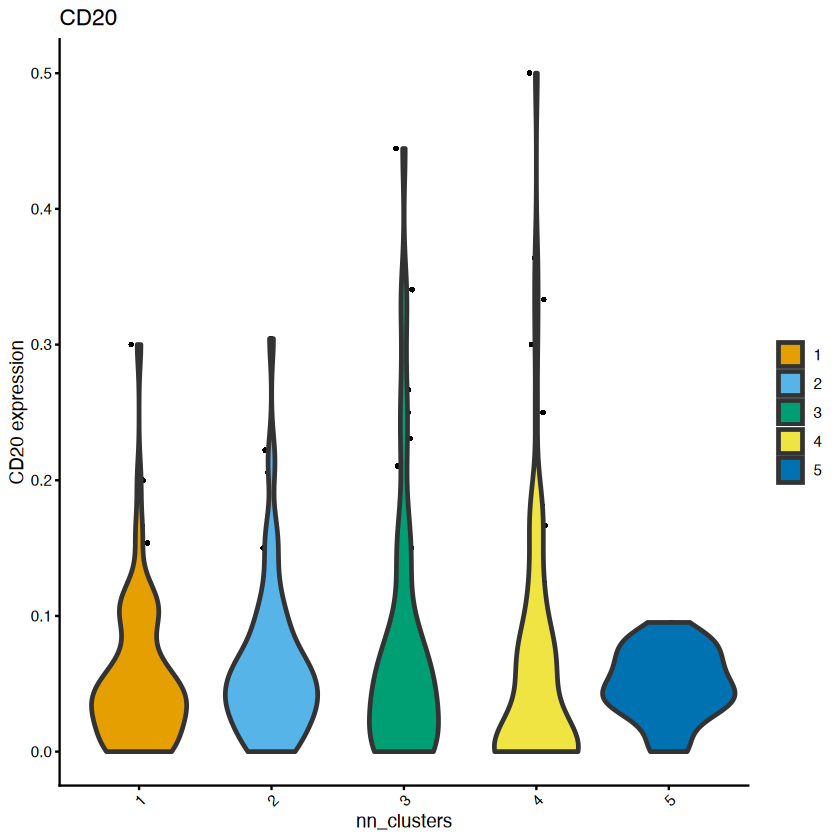

In [75]:
dittoPlot(spe, "CD20", group.by = "nn_clusters") +
coord_cartesian(ylim = c(0, 0.5))

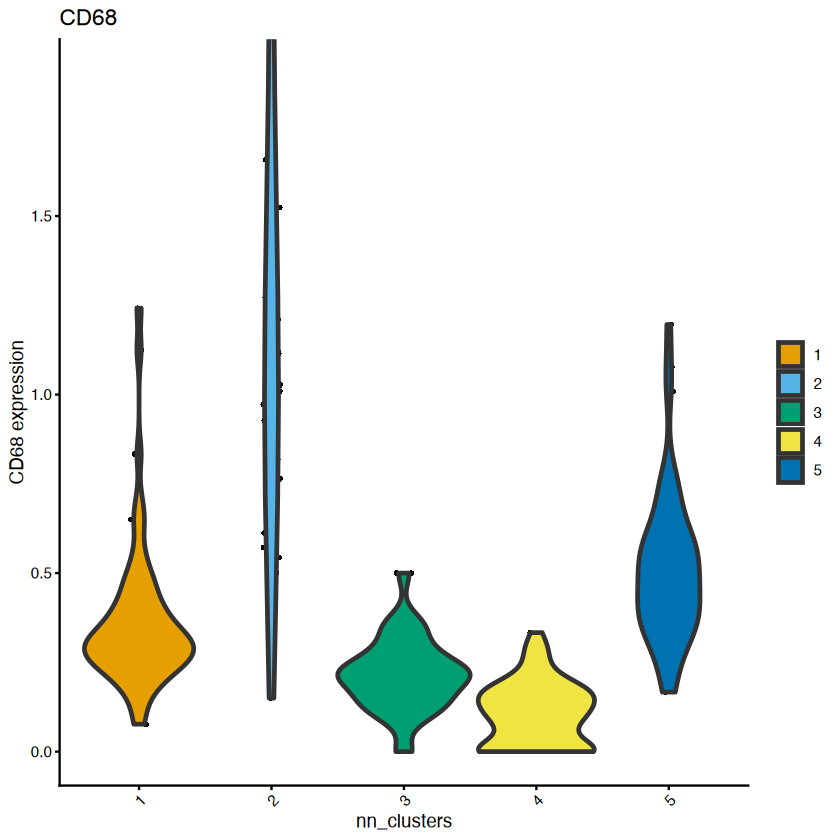

In [76]:
dittoPlot(spe, "CD68", group.by = "nn_clusters") +
coord_cartesian(ylim = c(0, 1.9))

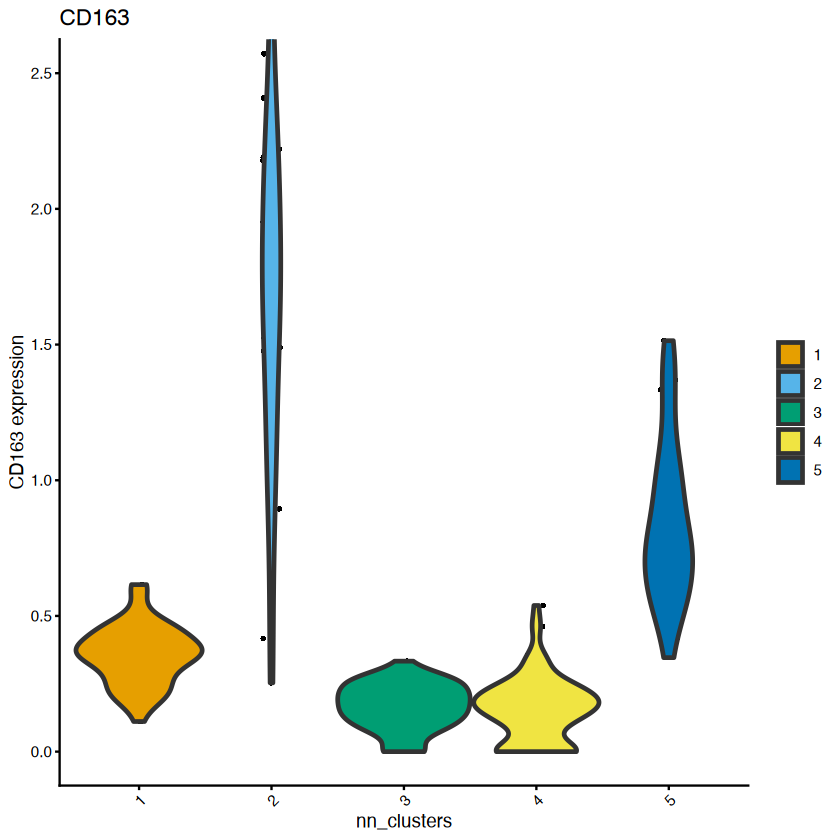

In [77]:
dittoPlot(spe, "CD163", group.by = "nn_clusters") +
coord_cartesian(ylim = c(0, 2.5))

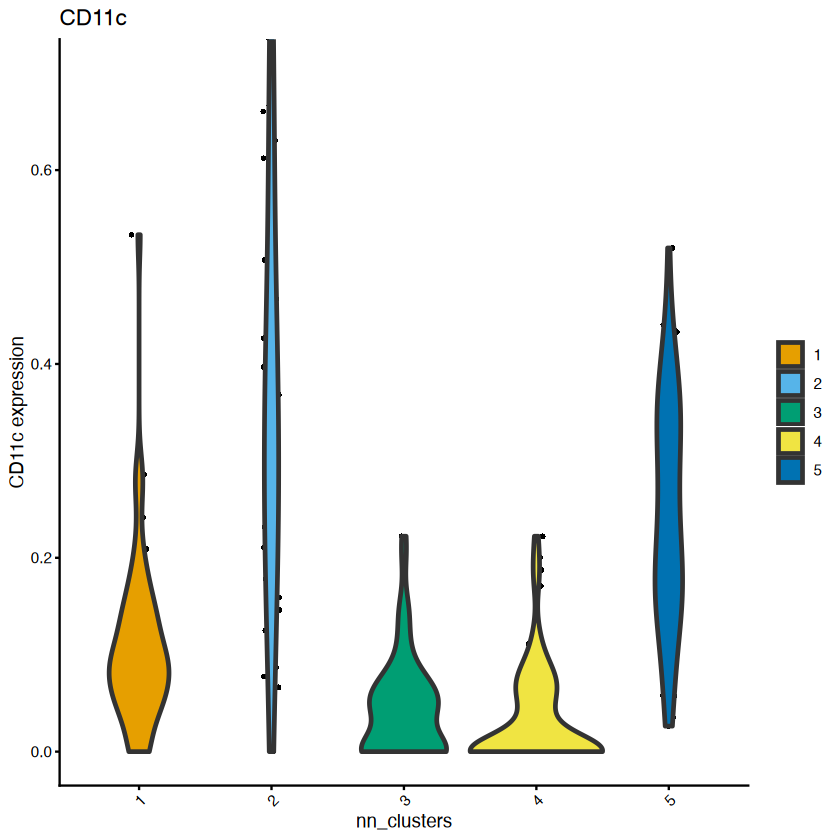

In [78]:
dittoPlot(spe, "CD11c", group.by = "nn_clusters") +
coord_cartesian(ylim = c(0, 0.7))

---

## 14. STEP 14. Assign biological cell-type names to clusters

- It converts numeric cluster IDs into **biological labels**
- WARNING:
   - assign labels manually.
   - The labelling should be performed according to the Heatmap
- **This is very important - labelling should be based on: heatmap and marker plots**


In [79]:
spe$celltype <- dplyr::recode(
  as.character(spe$nn_clusters),
###--- WARNING: 
  "1" = "Tumor",
  "2" = "CD8",
  "3" = "CD4",
  "4" = "Bcell",
  "5" = "Myeloid",
  "6" = "Stroma",
  "7" = "Treg",
  "8" = "Plasma_cell",
  "9" = "Neutrophil",
  .default = "Other"
)
# following table will show how many cells fall into each assigned cell types
table(spe$celltype)


  Bcell     CD4     CD8 Myeloid   Tumor 
     85      65      60      56      66 

---

## 15. STEP 15. Visualize annotated cell types on UMAP

- This plots UMAP, now coloured by the defined biological cell types
- This will generate the first phenotype map of the dataset

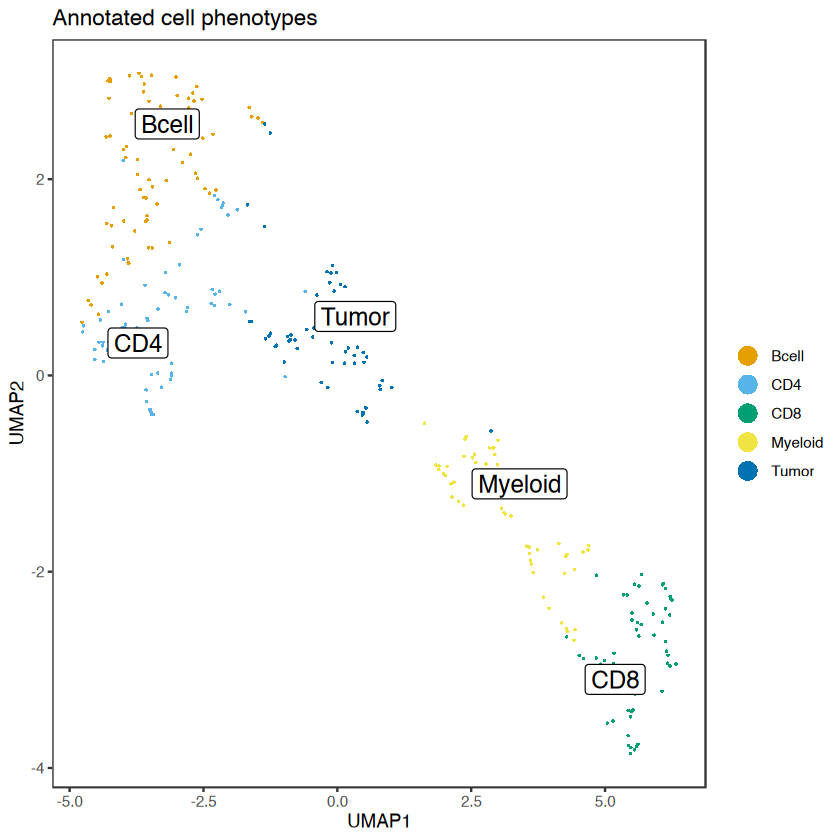

In [80]:
dittoDimPlot(
  spe,
  var = "celltype",
  reduction.use = "UMAP",
  size = 0.4,
  do.label = TRUE
) + ggtitle("Annotated cell phenotypes")

---

## 16. STEP 16. Check counts per sample or image

- This step counts how many cells of each type are present in each sample or patient
- It will show a table with cell types in rows and samples/patients in columns.
- It helps to see: 1) whether some cell types are abundant in certain samples, 2) whether tumor-rich or immune-rich samples exist, 3) whether some clusters are sample-specific

In [81]:
colnames(colData(spe))

[1] "sample_id"         "ObjectNumber"      "area"             
 [4] "axis_major_length" "axis_minor_length" "eccentricity"     
 [7] "width_px"          "height_px"         "nn_clusters"      
[10] "celltype"

In [82]:
table(spe$celltype, spe$sample_id)

         
          ROI001_D13
  Bcell           85
  CD4             65
  CD8             60
  Myeloid         56
  Tumor           66

## 17. STEP 17. Save the analyzed object


- This saves the current analysis object to disk.
- So one does not have to rerun everything next time.

In [83]:
saveRDS(spe, "data/spe_phenotyped_direct.rds")

---

---

<div style="text-align: center;">****--------****</div>

## Step 18. Heatmap Interpretation (Cluster -> Biology)



| Category            | Signature Markers                              | Observation in Data                          | Interpretation |
|--------------------|-----------------------------------------------|--------------------------------------------------|----------------|
| Tumor cells        | High Ecad, low immune markers                 | Strong Ecad signal in some clusters              | Tumor          |
| Myeloid cells      | CD68, CD163, HLADR, ± CD14/CD11c              | Multiple strong clusters                         | Myeloid (macrophage/APC) |
| CD4 T cells        | CD3 + CD4                                     | Moderate CD3/CD4 regions                         | CD4 T cells    |
| CD8 T cells        | CD3 + CD8a                                    | Distinct CD8-enriched cluster                    | CD8 T cells    |
| B cells            | CD20                                          | Clear CD20 spike cluster                         | B cells        |
| Plasma cells       | CD38                                          | Smaller CD38 clusters                            | Plasma cells   |
| Stroma             | PDGFRb / SMA                                  | Weaker but visible clusters                      | Stromal cells  |
| Regulatory T cells | FOXP3                                         | Low but present FOXP3 signal                     | Tregs (small population) |
| Neutrophils        | MPO + CD15                                    | Small MPO/CD15 signal                            | Neutrophils (rare) |

**Important Observations**
FOR EXAMPLE: 
- The dataset is: 1) **Myeloid-rich**, 2) moderate T cell infiltration, 3) clear tumor compartment

### 18.1 Now assign cell types properly based on the heatmap¶

- We will collapse cluster into cell types

In [84]:
# First check cluster numbers
table(spe$nn_clusters)


 1  2  3  4  5 
66 60 65 85 56 

In [85]:
##- Assign the cluster number a biological label based on heatmap interpretation

spe$celltype <- dplyr::recode(
  as.character(spe$nn_clusters),

  # Tumor (high Ecad)
  "1" = "Tumor",
  "5" = "Tumor",

  # Myeloid (CD68/CD163/HLADR)
  "2" = "Myeloid",
  "3" = "Myeloid",
  "6" = "Myeloid",
  "7" = "Myeloid",

  # CD4 T
  "4" = "CD4_T",

  # CD8 T
  "8" = "CD8_T",

  # B cells
  "9" = "B_cell",

  # Plasma
  "10" = "Plasma",

  # Stroma
  "11" = "Stroma",

  # Treg
  "12" = "Treg",

  # Neutrophil
  "13" = "Neutrophil",

  .default = "Other"
)

**This is very important step, one must: 1) Check cluster > marker pattern, 2) adjust cluster number if needed**

### 18.2 Visualize final annotation

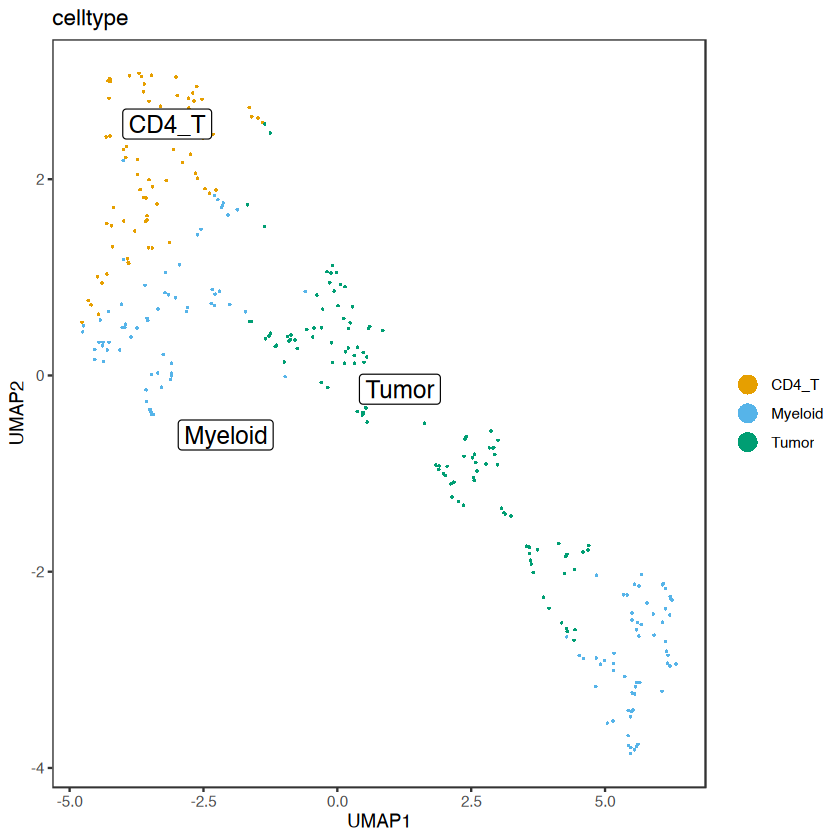

In [86]:
dittoDimPlot(
  spe,
  var = "celltype",
  reduction.use = "UMAP",
  size = 0.4,
  do.label = TRUE
)

### 18.3 Check Composition

In [87]:
table(spe$celltype)


  CD4_T Myeloid   Tumor 
     85     125     122 

In [88]:
# per sample composition
table(spe$celltype, spe$sample_id)

         
          ROI001_D13
  CD4_T           85
  Myeloid        125
  Tumor          122

---